In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## 1 SVM hard-margin sur un problème jouet
Reprenons le problème synthétique du TP4 : $(x, y_i) ∈ R^2 × {λ_1, λ_2}$, et $λ_1 ∼ N (μ_1, σ^2_1 )$ et $λ_2 ∼N (μ_2, σ^2_2 )$.
1. Générez cette base de données telle que :
- chaque classe contient 300 points
- $λ_1 ∼ N ((1, 1), 0.4)$ et $λ_2 ∼ N ((−1, −1), 0.4)$

In [2]:
n = 300
c1 = np.random.normal((1,1), 0.4, (n, 2))
c2 = np.random.normal((-1,-1), 0.4, (n, 2))

2. Etiquetez les points pour pouvoir entrainer un SVM par la suite

In [3]:
labels_1 = np.ones(n) # c1 = 1
labels_2 = -np.ones(n) # c2 = 0

X = np.vstack((c1, c2))
y = np.hstack((labels_1, labels_2))

3. Affichez le nuage de points. Le problème est-il linéairement séparable ?

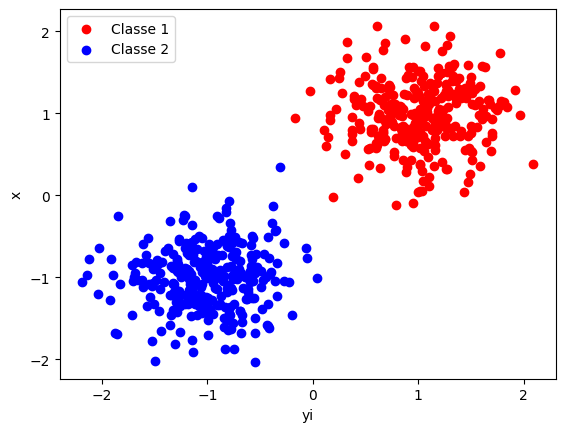

In [4]:
def plot_data():
    plt.scatter(c1[:, 0], c1[:, 1], color='red', label='Classe 1')
    plt.scatter(c2[:, 0], c2[:, 1], color='blue', label='Classe 2')
    plt.legend()
    plt.xlabel("yi")
    plt.ylabel("x")
    plt.show()

plot_data()

Yes, the problem appears to be lenearly separable, because we decreased the spread of the cloud.

On propose d’entraîner un SVM linéaire sur ces données et de visualiser la frontière de décision et les points supports. Pour cela, vous allez utiliser la classe SVC de Scikit-learn. Cette implémentation correspond au SVM soft-margin, c’est-à-dire en tolérant des erreurs d’apprentissage.

4. Proposez une paramétrisation de SVC pour vous assurer :
- que le modèle est bien linéaire
- qu’il n’y a pas de données d’apprentissage mal classées

Justifiez brièvement cette paramétrisation.

In [5]:
scaler = StandardScaler()
X_n = scaler.fit_transform(X)
kernel='linear'
C=100000

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Using a linear kernel ensures that the separating hyperplane is an affine plane (a line in this 2d case). A high value of C forces the model to avoid errors on the training set, as it heavily penalizes misclassified points, as clusters are linearly separable, a high value of C is a safe choice.
  </p>
</div>

5. Entrainez un SVM avec cette paramétrisation sur l’ensemble des données

In [6]:
clf = SVC(kernel=kernel, C=C)
clf.fit(X_n, y)

SVC(C=100000, kernel='linear')

6. Du modèle appris, récupérez et affichez :
- les indices des vecteurs supports
- le vecteur α solution du problème dual
- le biais b

Combien de valeurs contient alphas ? Pourquoi ?

In [7]:
indice_SV = clf.support_
alphas = clf.dual_coef_[0]
b = clf.intercept_
print(f"Indices of support vectors: {indice_SV}, \nDual coefficients: {alphas}, \nIntercept: {b}")
print(f"Alphas has {len(alphas)} values")

Indices of support vectors: [377  21  43], 
Dual coefficients: [-19.7291379    9.81807506   9.91106284], 
Intercept: [-0.07529587]
Alphas has 3 values


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The size of alphas is equal to the number of support vectors. Only these vectors have a non-zero dual coefficient.
  </p>
</div>

7. À partir de ces valeurs, calculez le vecteur w

In [ ]:
# Récupérer les vecteurs supports et leurs étiquettes
X_sv = X_n[indice_SV]
y_sv = y[indice_SV]

# Calculer w à partir des vecteurs supports et des alphas
w_calculated = np.sum(alphas.reshape(-1, 1) * X_sv, axis=0)
w_svm = clf.coef_[0]

# Exibição dos resultados
print("Vecteur w (calculé) :", w_calculated)
print("Vecteur w (SVM) :", w_svm)

Vecteur w (calculé) : [5.88302932 2.19924662]
Vecteur w (SVM) : [5.88302932 2.19924662]


8. Verifiez que les points supports sont telles que $h(x) = w^tx + b = ±1$

In [24]:
h_values_calculated = np.dot(X[indice_SV], w_calculated) + b

print(f"Valeurs de h(x) (calculé): {h_values_calculated}")



Valeurs de h(x) (calculé): [-1.15878019  0.98891427  1.03322049]


9. Sur une même figure, affichez :
- le nuage de points
- la frontière de décision h(x) = 0
- les frontières de marge h(x) = ±1
- les points supports

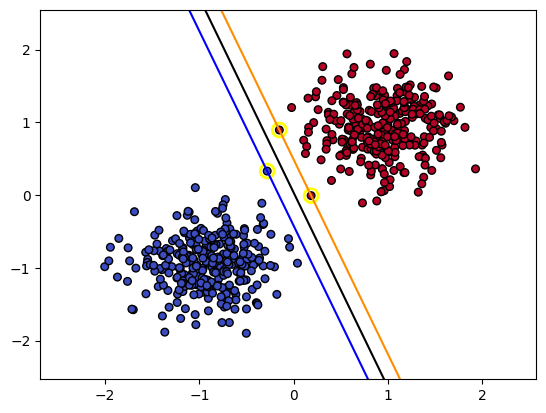

In [ ]:
def mesh(X, h=0.02):
    x_min , x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min , y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min , x_max , h), np.arange(y_min , y_max , h))
    return np.c_[xx.ravel(), yy.ravel()], xx, yy
xtest_grid , x_grid , y_grid = mesh(X)
Z = xtest_grid @ w_calculated + b
Z = Z.reshape(x_grid.shape)
# Plot decision and support boundaries:
plt.contour(x_grid , y_grid , Z, colors=['blue', 'black', 'darkorange'], levels=[-1, 0, 1])
plt.scatter(X_n[:, 0], X_n[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=30) # Plot data points and support vectors
plt.scatter(X_n[indice_SV, 0], X_n[indice_SV, 1], s=100, facecolors='none', edgecolors='yellow', linewidth=2, label="Support Vectors") # Vecteurs support points
plt.show()


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can observe that the high value of C allowed an easy separation of the clusters. Three points were found as support for the vectors, as expected according to the number of elements in Alphas.
  </p>
</div>

## 2 SVM soft-margin sur un problème jouet
Dans ce deuxième exercice, on propose de reprendre la même expérience mais en augmentant les variances σ1 et σ2.

1. Générez la même base de données mais cette fois telle que :
- chaque classe contient 300 points
- λ1 ∼ N ((1, 1), 0.7) et λ2 ∼ N ((−1, −1), 0.7)

In [26]:
n = 300
c1 = np.random.normal((1,1), 0.7, (n, 2))
c2 = np.random.normal((-1,-1), 0.7, (n, 2))

2. Le problème est-il linéairement séparable ?

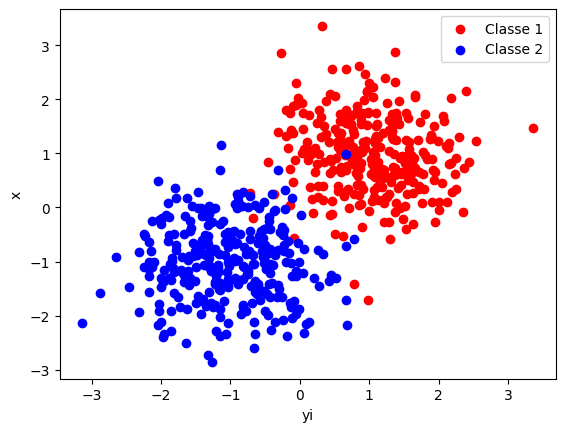

In [44]:
labels_1 = np.ones(n) # c1 = 1
labels_2 = -np.ones(n) # c2 = 0

X = np.vstack((c1, c2))
y = np.hstack((labels_1, labels_2))
plot_data()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The problem is not linearly separable, so an appropriate value of C should be defined for a good compromise between the error and the margin size.
  </p>
</div>

3. Entrainez un SVM linéaire avec la même paramétrisation que précédemment et affichez de
nouveau la frontière de décision et les points supports. Commentez brievement ce que vous
observez.

In [45]:
scaler = StandardScaler()
X_n = scaler.fit_transform(X)
clf = SVC(kernel='linear', C=0.2683)
clf.fit(X_n, y)

SVC(C=0.2683, kernel='linear')

In [46]:
indice_SV = clf.support_
alphas = clf.dual_coef_[0]
b = clf.intercept_
print(f"Indices of support vectors: {indice_SV}, \nDual coefficients: {alphas}, \nIntercept: {b}")
print(f"Alphas has {len(alphas)} values")

Indices of support vectors: [301 321 331 340 342 367 392 407 442 443 445 459 488 492 512 515 516 517
 520 526 528 530 560 565 568 579 585 595   2   4  19  25  29  63  65  69
  88 101 112 126 128 132 137 166 175 192 216 219 230 239 270 273 276 292
 293], 
Dual coefficients: [-0.2683     -0.2683     -0.2683     -0.21902845 -0.2683     -0.2683
 -0.2683     -0.2683     -0.2683     -0.2683     -0.2683     -0.2683
 -0.2683     -0.2683     -0.2683     -0.2683     -0.2683     -0.2683
 -0.2683     -0.2683     -0.2683     -0.2683     -0.2683     -0.2683
 -0.2683     -0.04927155 -0.2683     -0.2683      0.2683      0.2683
  0.2683      0.2683      0.2683      0.2683      0.2683      0.2683
  0.2683      0.2683      0.2683      0.2683      0.2683      0.2683
  0.2683      0.2683      0.2683      0.2683      0.2683      0.2683
  0.2683      0.2683      0.2683      0.2683      0.2683      0.2683
  0.2683    ], 
Intercept: [-0.1124011]
Alphas has 55 values


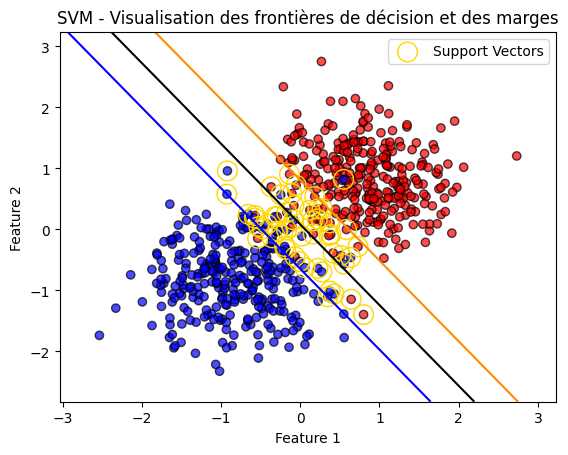

In [47]:
# Créer la grille pour le tracé
xtest_grid , x_grid , y_grid = mesh(X_n)

# Prédire les valeurs de la grille pour obtenir les contours
Z = clf.decision_function(xtest_grid)
Z = Z.reshape(x_grid.shape)

# Tracer la frontière de décision et les frontières des marges
plt.contour(x_grid, y_grid, Z, colors=['blue', 'black', 'darkorange'], levels=[-1, 0, 1])

# Tracer les points et les vecteurs supports
plt.scatter(X_n[:, 0], X_n[:, 1], c=y, cmap="bwr", alpha=0.7, edgecolors="k")
plt.scatter(X_n[indice_SV, 0], X_n[indice_SV, 1], s=200, edgecolors="gold", facecolors="none", label="Support Vectors")

# Ajouter les labels et afficher le graphique
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.title("SVM - Visualisation des frontières de décision et des marges")
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We observe that in this new example the number of support points is much greater, all 55 points are being considered to define the support vectors.
  </p>
</div>

4. Que se passe-t-il si vous modifiez la valeur du paramètre C de la méthode SVC ?

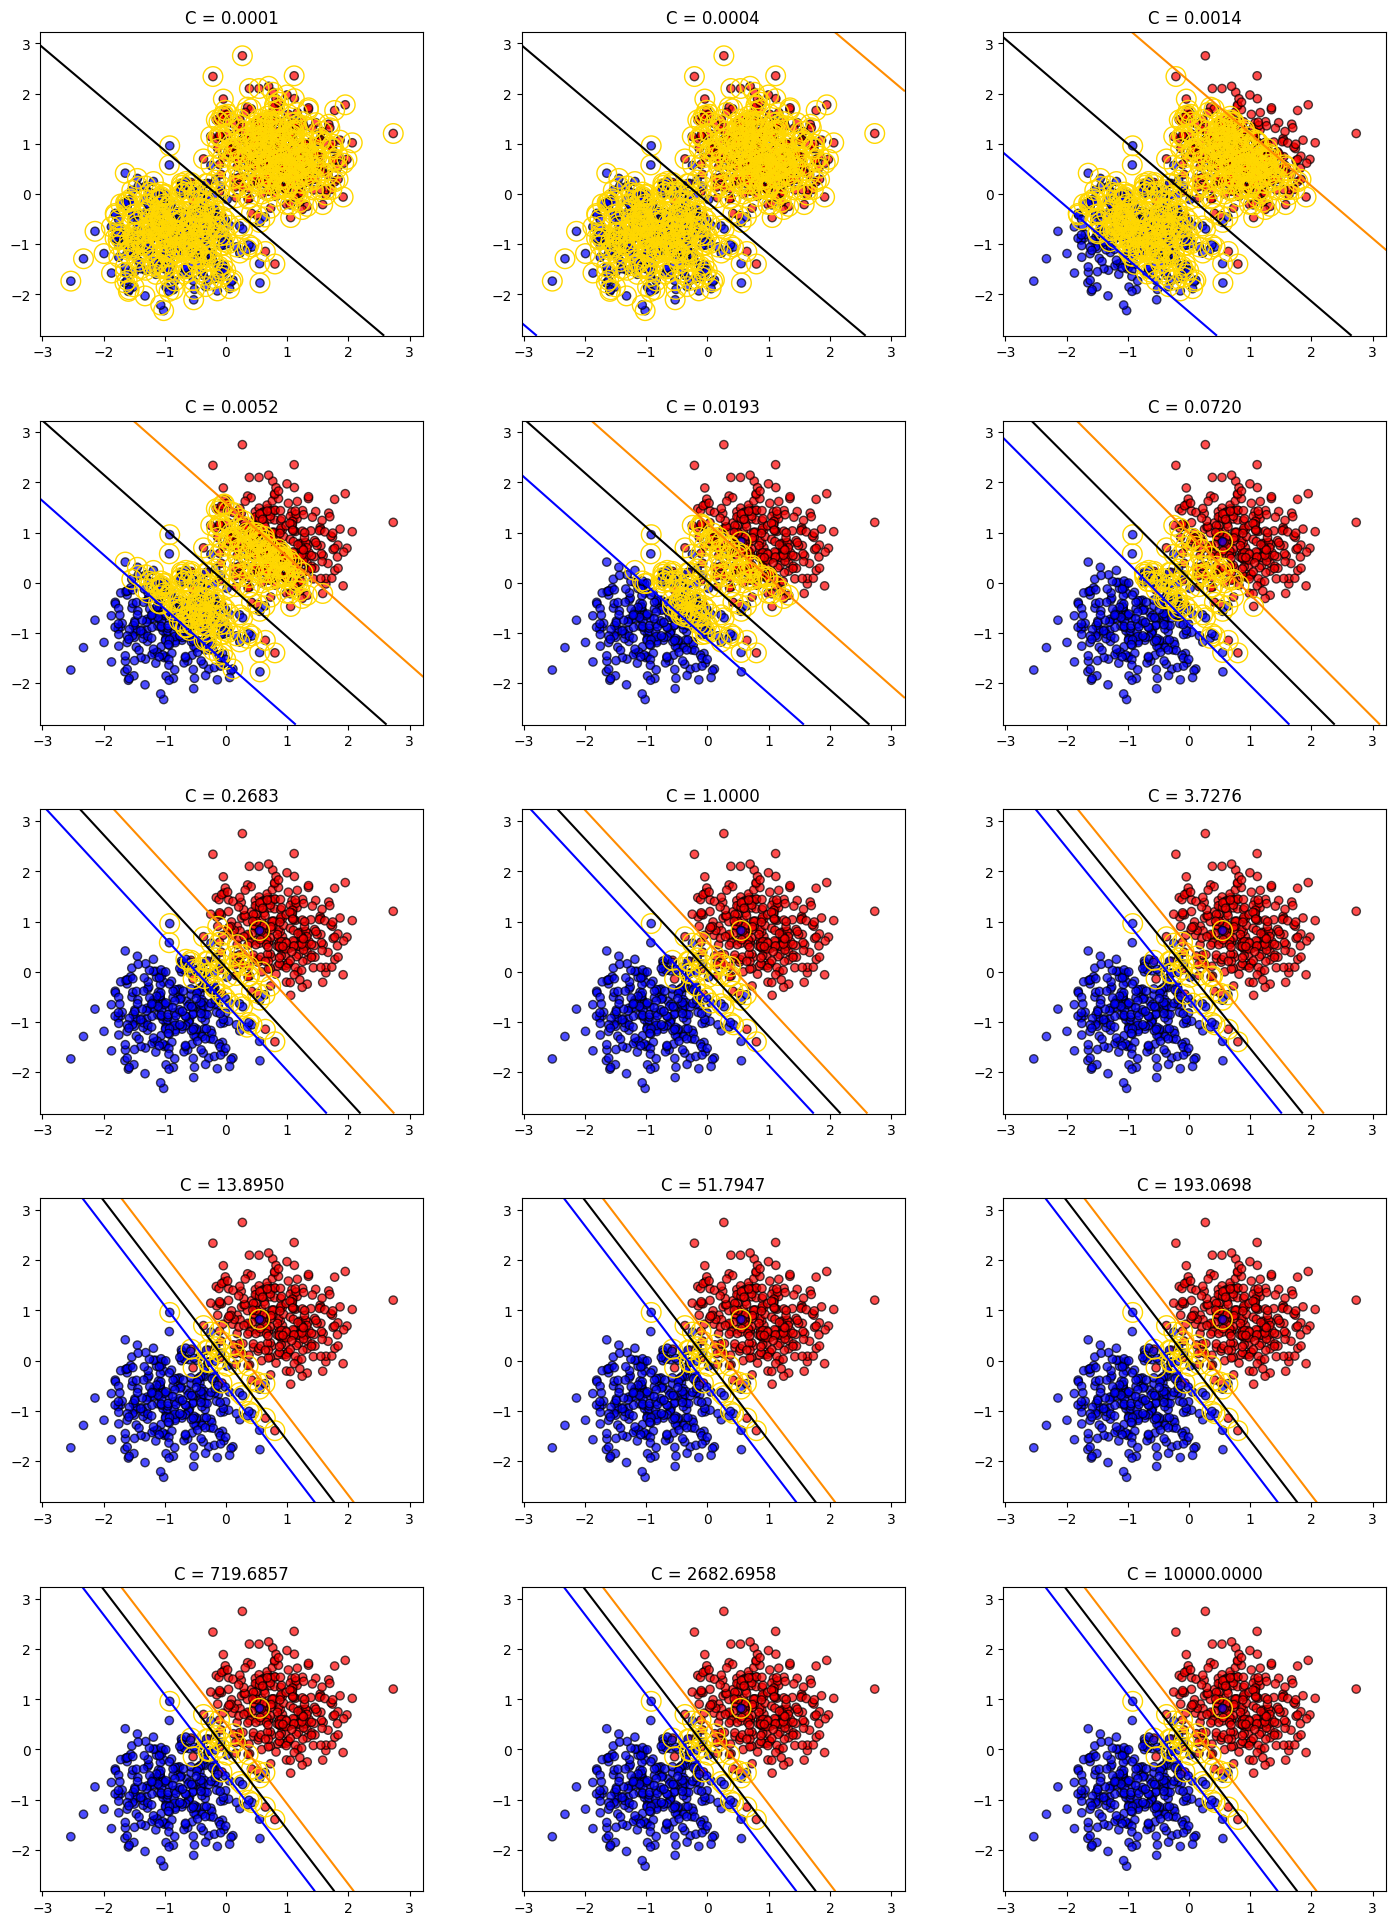

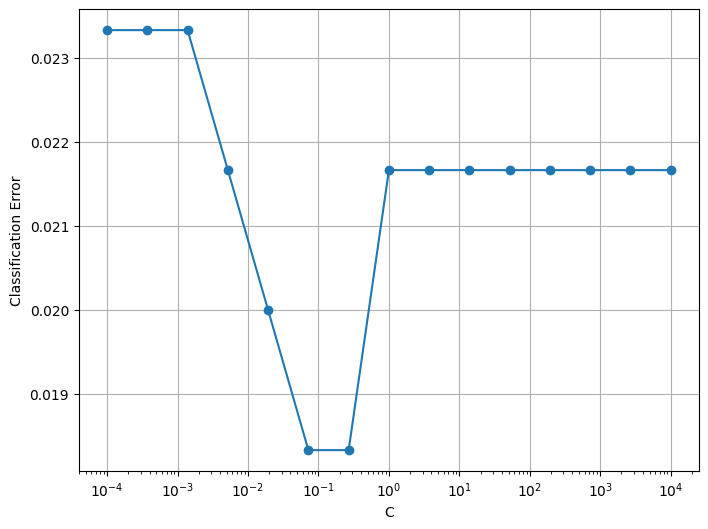

In [48]:

C_values = np.logspace(-4, 4, 15)  # C between 10^-4 e 10^4
classification_errors = [] 

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
fig.tight_layout(pad=4.0) 

for i, (C, ax) in enumerate(zip(C_values, axes.flat)):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_n, y)

    y_pred = clf.predict(X_n)
    error = 1 - accuracy_score(y, y_pred)  # Classification Error
    classification_errors.append(error)

    xtest_grid, x_grid, y_grid = mesh(X_n)
    Z = clf.decision_function(xtest_grid)
    Z = Z.reshape(x_grid.shape)
    ax.contour(x_grid, y_grid, Z, colors=['blue', 'black', 'darkorange'], levels=[-1, 0, 1])
    ax.scatter(X_n[:, 0], X_n[:, 1], c=y, cmap="bwr", alpha=0.7, edgecolors="k")
    ax.scatter(X_n[clf.support_, 0], X_n[clf.support_, 1], s=200, edgecolors="gold", facecolors="none", label="Support Vectors")
    ax.set_title(f"C = {C:.4f}")
plt.show()

plt.figure(figsize=(8, 6))
plt.semilogx(C_values, classification_errors, marker='o')
plt.xlabel('C')
plt.ylabel('Classification Error')
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We tested C values ​​over a wide range, from 10<sup>-4</sup> to 10<sup>4</sup>, and we observed that the higher the C value, the smaller the margin size. There must be a compromise to find the plan that maximizes the margin and minimizes the error (distance from the support points to the support line). Since the C value increases the error term, its increase causes this effect of decreasing the margin. However, we see that values ​​in the center of the C value range were ideal for this example, as they guaranteed the smallest error in the test data.
  </p>
</div>